# Breast Cancer Wisconsin (Diagnostic): Benign vs Malignant Classification

**Goal:** predict whether a breast mass is malignant or benign from 30 numeric features computed from digitised fine-needle-aspirate images, and evaluate the models in a way that is honest about generalisation.

**Data:** UCI *Breast Cancer Wisconsin (Diagnostic)*, 569 samples, 30 features (mean / standard error / worst of 10 cell-nucleus measurements), 212 malignant and 357 benign. No missing values.

**Approach**
1. Exploratory analysis (class balance, distributions, correlations)
2. Stratified 80/20 train/test split; the test set is used only for final checks
3. Logistic Regression vs Random Forest, both inside leakage-free `Pipeline`s
4. **Nested cross-validation** (3-fold inner tuning, 5-fold outer evaluation); the final model is chosen from these results programmatically
5. Test-set evaluation, feature importance, and a **decision threshold tuned on training data only** to favour recall

**Headline results**
- Selected model: **Logistic Regression** (nested-CV ROC-AUC 0.995, accuracy 0.974, recall 0.941)
- On the held-out test set with a training-data-tuned threshold of 0.30: **recall 0.976, precision 0.976, 1 false negative and 1 false positive out of 114 samples**

> This is an educational project. It is **not** a clinical tool.

## 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV,
    cross_validate, cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
sns.set_style("whitegrid")
os.makedirs("images", exist_ok=True)   # figures used in the README

## 2. Load Dataset

The data ships with scikit-learn, so the notebook runs anywhere without an external CSV. Column names are converted to the familiar Kaggle/UCI style (`radius_mean`, `radius_se`, `radius_worst`).

In [2]:
raw = load_breast_cancer(as_frame=True)
df = raw.frame.copy()

def to_uci_name(col):
    if col.startswith("mean "):   return col[len("mean "):] + "_mean"
    if col.startswith("worst "):  return col[len("worst "):] + "_worst"
    if col.endswith(" error"):    return col[:-len(" error")] + "_se"
    return col

df = df.rename(columns=to_uci_name)

# scikit-learn encodes malignant=0 / benign=1. Flip it so the clinically
# important class (malignant) is the positive class = 1.
df["diagnosis"] = 1 - df["target"]
df = df.drop(columns="target")
df = df[["diagnosis"] + [c for c in df.columns if c != "diagnosis"]]

print(df.shape)
df.head()

(569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Basic Information

In [3]:
df.info()
print("\nTotal missing values:", int(df.isnull().sum().sum()))
print("\nClass counts (0 = Benign, 1 = Malignant):")
print(df["diagnosis"].value_counts())
print("\nMalignant share: {:.1%}".format(df["diagnosis"].mean()))

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

## 4. Exploratory Data Analysis

### 4.1 Class balance

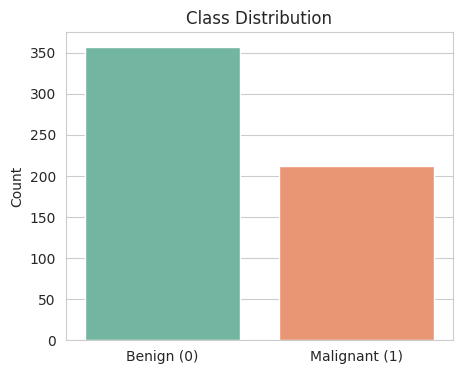

In [4]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(x="diagnosis", hue="diagnosis", data=df, palette="Set2", legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Benign (0)", "Malignant (1)"])
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.set_title("Class Distribution")
plt.show()

**Takeaway:** 357 benign (62.7%) vs 212 malignant (37.3%). The imbalance is moderate, so all splits are stratified, and accuracy alone would be a misleading metric. Precision, recall, F1 and ROC-AUC are reported too.

### 4.2 Feature distributions by diagnosis

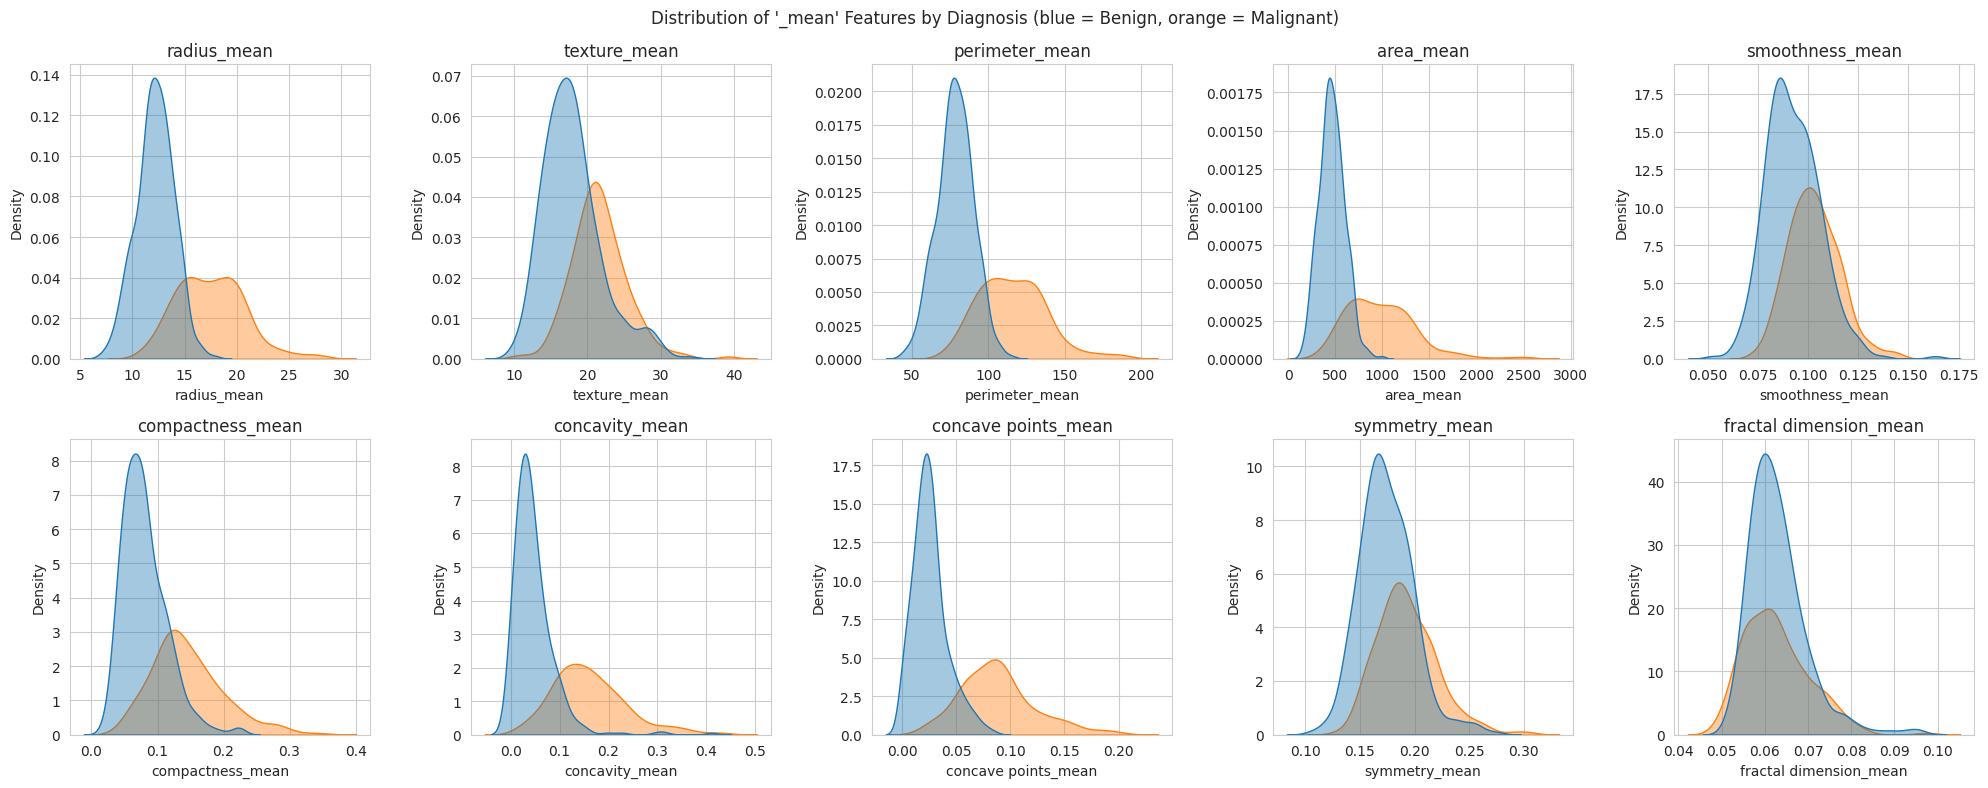

In [5]:
mean_features = [c for c in df.columns if c.endswith("_mean")]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, feature in zip(axes.flatten(), mean_features):
    sns.kdeplot(data=df, x=feature, hue="diagnosis", fill=True, alpha=0.4, ax=ax, legend=False)
    ax.set_title(feature)
plt.suptitle("Distribution of '_mean' Features by Diagnosis (blue = Benign, orange = Malignant)")
plt.tight_layout()
plt.show()

### 4.3 Boxplots of key features

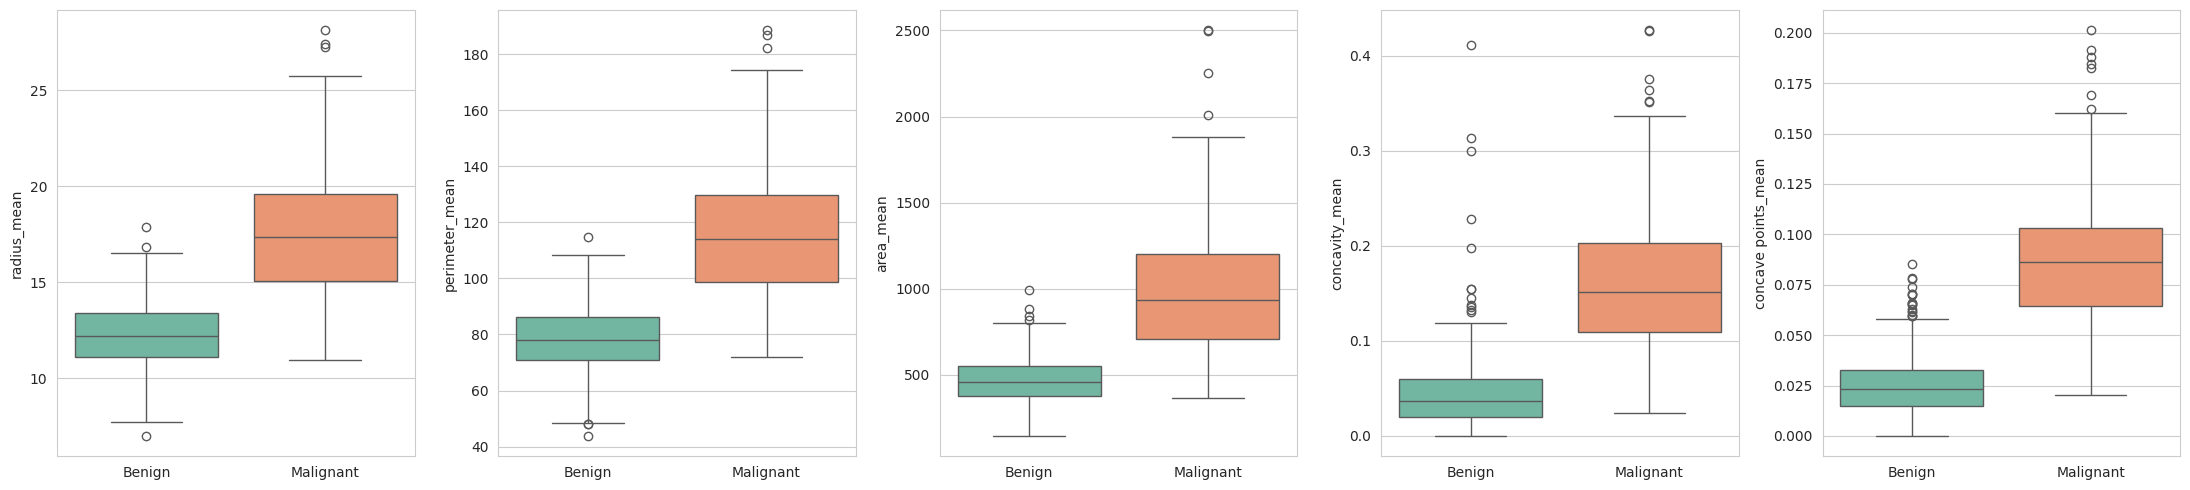

In [6]:
key_features = ["radius_mean", "perimeter_mean", "area_mean", "concavity_mean", "concave points_mean"]

fig, axes = plt.subplots(1, len(key_features), figsize=(22, 5))
for ax, feature in zip(axes, key_features):
    sns.boxplot(x="diagnosis", y=feature, hue="diagnosis", data=df, ax=ax, palette="Set2", legend=False)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Benign", "Malignant"])
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

**Takeaway:** for size and shape-irregularity features (radius, perimeter, area, concavity, concave points), the malignant distribution is clearly shifted to higher values with limited overlap. Features such as smoothness, symmetry and fractal dimension overlap heavily between classes, so they look like weaker individual discriminators.

### 4.4 Correlations

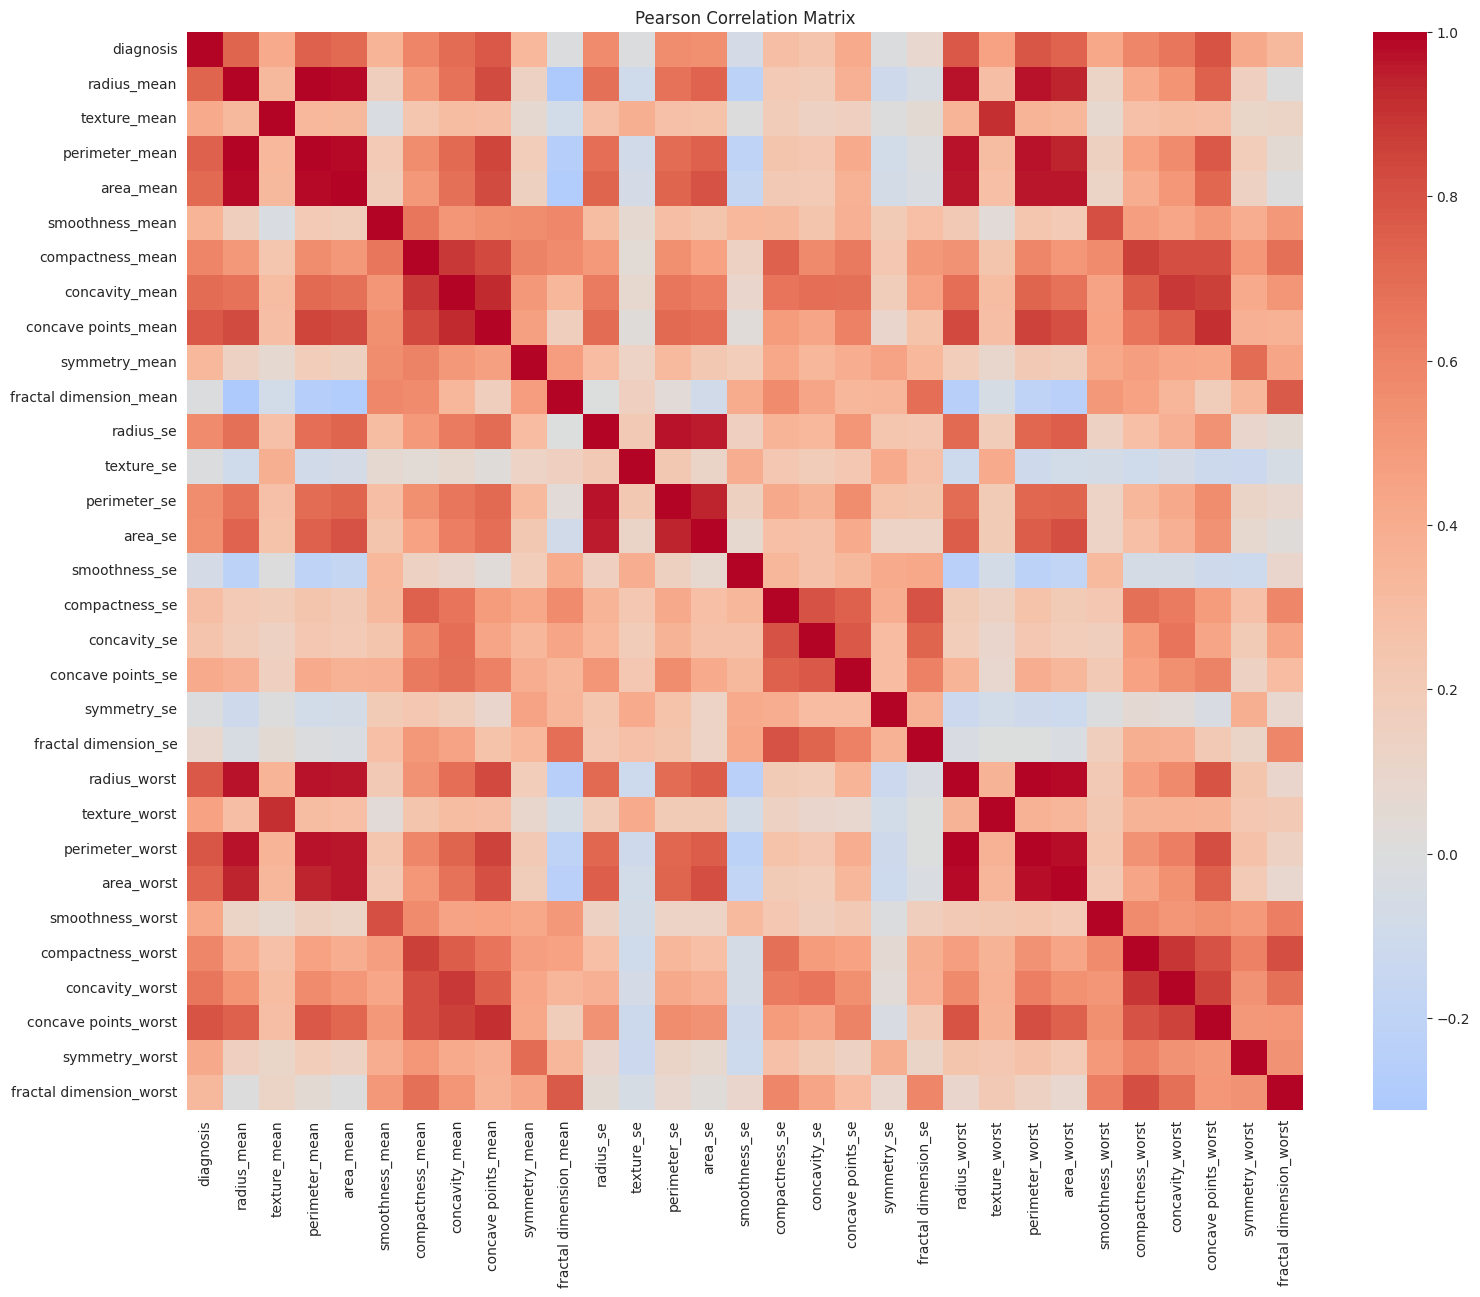

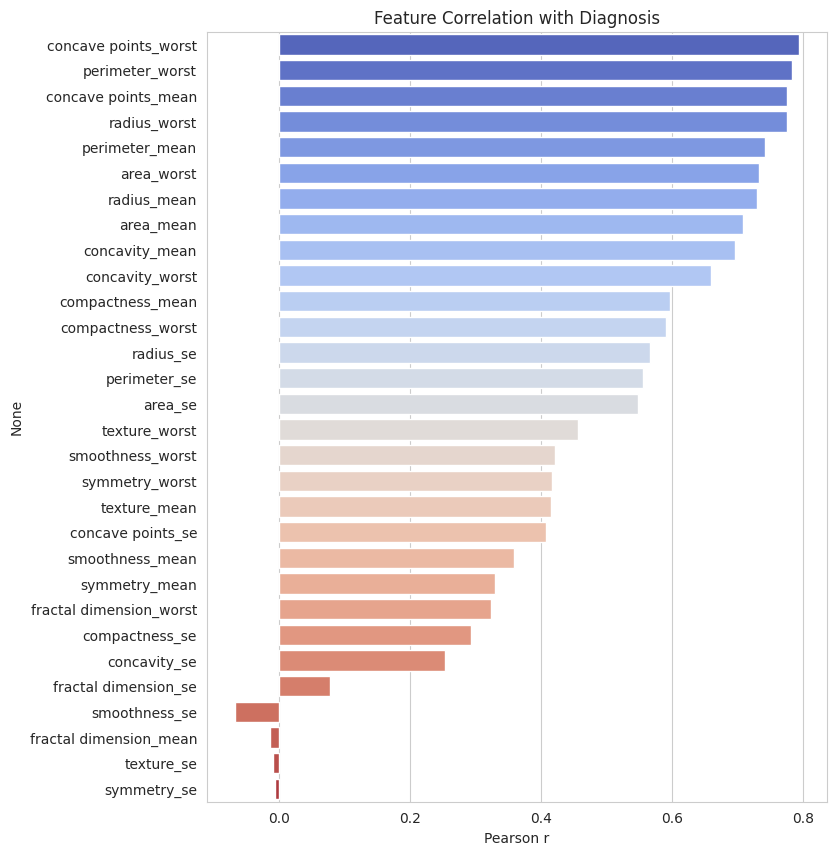

In [7]:
corr_matrix = df.corr(method="pearson")

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0)
plt.title("Pearson Correlation Matrix")
plt.show()

target_corr = corr_matrix["diagnosis"].drop("diagnosis").sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(x=target_corr.values, y=target_corr.index, hue=target_corr.index,
            palette="coolwarm", legend=False)
plt.title("Feature Correlation with Diagnosis")
plt.xlabel("Pearson r")
plt.show()

In [8]:
# How redundant are the features? (multicollinearity check)
print(corr_matrix.loc[["radius_mean", "perimeter_mean", "area_mean"],
                      ["radius_mean", "perimeter_mean", "area_mean"]].round(3))

feat_corr = df.drop(columns="diagnosis").corr().abs()
upper = feat_corr.where(np.triu(np.ones(feat_corr.shape, dtype=bool), k=1))
n_pairs = int((upper > 0.9).sum().sum())
print(f"\nFeature pairs with |r| > 0.9: {n_pairs}")

                radius_mean  perimeter_mean  area_mean
radius_mean           1.000           0.998      0.987
perimeter_mean        0.998           1.000      0.987
area_mean             0.987           0.987      1.000

Feature pairs with |r| > 0.9: 21


**Takeaways**
- The features are highly redundant: `radius_mean`, `perimeter_mean` and `area_mean` are correlated at 0.987 to 0.998, and 21 feature pairs have |r| > 0.9 (mean, SE and worst versions of the same measurement also move together).
- Features most correlated with the diagnosis: `concave points_worst` (0.79), `perimeter_worst` (0.78), `concave points_mean` (0.78) and `radius_worst` (0.78).
- **Why it matters:** for Logistic Regression, strong multicollinearity makes individual coefficients unstable and hard to interpret (the L2 penalty, tuned through `C`, keeps the predictions well-behaved). For Random Forest, correlated features do not hurt prediction, but importance gets split among them. No features were dropped because the goal is prediction, not coefficient interpretation.

## 5. Train/Test Split

20% of the data is held out and touched only for the final evaluation. All model selection and threshold tuning happens on the training portion.

In [9]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Malignant share  train: {:.1%}  test: {:.1%}".format(y_train.mean(), y_test.mean()))

Train: (455, 30)  Test: (114, 30)
Malignant share  train: 37.4%  test: 36.8%


## 6. Models, Pipelines and Hyperparameter Grids

Scaling lives inside the `Pipeline`, so it is re-fit on the training folds only and never sees validation data (no leakage).

In [10]:
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(random_state=RANDOM_STATE))
])

lr_grid = {"model__C": [0.01, 0.1, 1, 10, 100]}

rf_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 5]
}

## 7. Nested Cross-Validation

The inner loop (3-fold) tunes hyperparameters; the outer loop (5-fold) estimates how well the *whole tuning procedure* generalises. This avoids the optimistic bias you get when the same folds are used for both tuning and scoring.

In [11]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

cv_metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]

lr_search = GridSearchCV(lr_pipeline, lr_grid, cv=inner_cv, scoring="roc_auc", n_jobs=-1)
rf_search = GridSearchCV(rf_pipeline, rf_grid, cv=inner_cv, scoring="roc_auc", n_jobs=-1)

lr_scores = cross_validate(lr_search, X_train, y_train, cv=outer_cv, scoring=cv_metrics)
rf_scores = cross_validate(rf_search, X_train, y_train, cv=outer_cv, scoring=cv_metrics)

### 7.1 Compare models

Nested CV results (mean ± std over 5 outer folds)


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.974 ± 0.011,0.989 ± 0.023,0.941 ± 0.032,0.964 ± 0.016,0.995 ± 0.004
Random Forest,0.965 ± 0.015,0.964 ± 0.011,0.941 ± 0.042,0.952 ± 0.021,0.989 ± 0.007


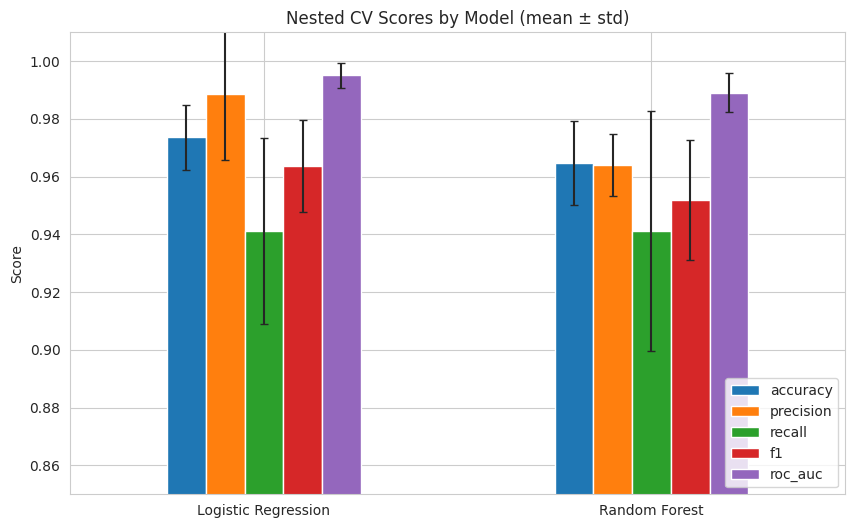

In [12]:
all_scores = {"Logistic Regression": lr_scores, "Random Forest": rf_scores}

cv_means = pd.DataFrame({name: {m: s[f"test_{m}"].mean() for m in cv_metrics}
                         for name, s in all_scores.items()}).T
cv_stds  = pd.DataFrame({name: {m: s[f"test_{m}"].std() for m in cv_metrics}
                         for name, s in all_scores.items()}).T

print("Nested CV results (mean ± std over 5 outer folds)")
display((cv_means.round(3).astype(str) + " ± " + cv_stds.round(3).astype(str)))

cv_means.plot(kind="bar", yerr=cv_stds, figsize=(10, 6), capsize=3)
plt.title("Nested CV Scores by Model (mean ± std)")
plt.ylabel("Score")
plt.ylim(0.85, 1.01)
plt.legend(loc="lower right")
plt.xticks(rotation=0)
plt.show()

### 7.2 Select the final model

The winner is chosen **programmatically from the nested-CV ROC-AUC**, not by hand and not by looking at the test set.

In [13]:
best_name = cv_means["roc_auc"].idxmax()
print(f"Selected model (highest nested-CV ROC-AUC): {best_name}")

searches = {"Logistic Regression": lr_search, "Random Forest": rf_search}
for name, search in searches.items():
    search.fit(X_train, y_train)          # refit tuning on the full training set
    print(f"{name}: best params = {search.best_params_}")

best_model = searches[best_name].best_estimator_
best_model

Selected model (highest nested-CV ROC-AUC): Logistic Regression


Logistic Regression: best params = {'model__C': 1}


Random Forest: best params = {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 100}


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work

**Takeaways**
- Logistic Regression scored higher than Random Forest on nested-CV ROC-AUC (0.995 vs 0.989), accuracy (0.974 vs 0.965), precision and F1. Recall was tied at 0.941.
- The gaps are small, comparable to the fold-to-fold standard deviations (about 0.004 to 0.007 for ROC-AUC), but they point in one direction. A regularised linear model is enough here, which suggests the classes are close to linearly separable in standardised feature space.
- Logistic Regression is therefore the final model. On the test set below, Random Forest gets one more sample right (see the table); that is **not** used to change the choice, because selecting a model by peeking at the test set would defeat its purpose.

## 8. Test-Set Evaluation

Both models are scored on the untouched test set for transparency, but the final model was already fixed by cross-validation above.

In [14]:
def evaluate(model, threshold=0.5):
    prob = model.predict_proba(X_test)[:, 1]
    pred = (prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    return {
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, prob),
        "FP": fp, "FN": fn,
    }

test_table = pd.DataFrame({name: evaluate(s.best_estimator_) for name, s in searches.items()}).T
test_table[["FP", "FN"]] = test_table[["FP", "FN"]].astype(int)
print("Test-set metrics at the default 0.5 threshold")
test_table.round(3)

Test-set metrics at the default 0.5 threshold


,accuracy,precision,recall,f1,roc_auc,FP,FN
Logistic Regression,0.965,0.975,0.929,0.951,0.996,1,3
Random Forest,0.974,1.000,0.929,0.963,0.993,0,3


### 8.1 Confusion matrix (final model, threshold 0.5)

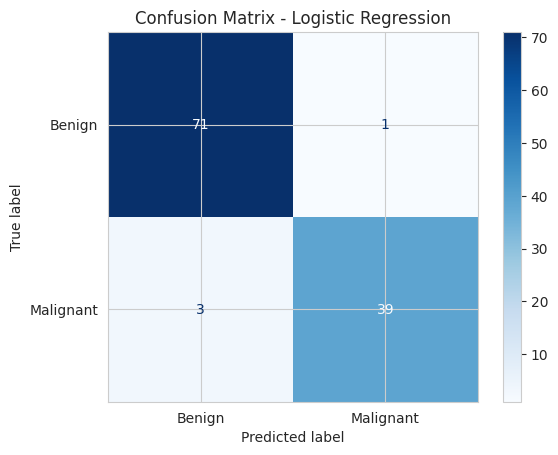

In [15]:
y_prob = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Benign", "Malignant"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_name}")
plt.savefig("images/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.2 ROC and Precision-Recall curves

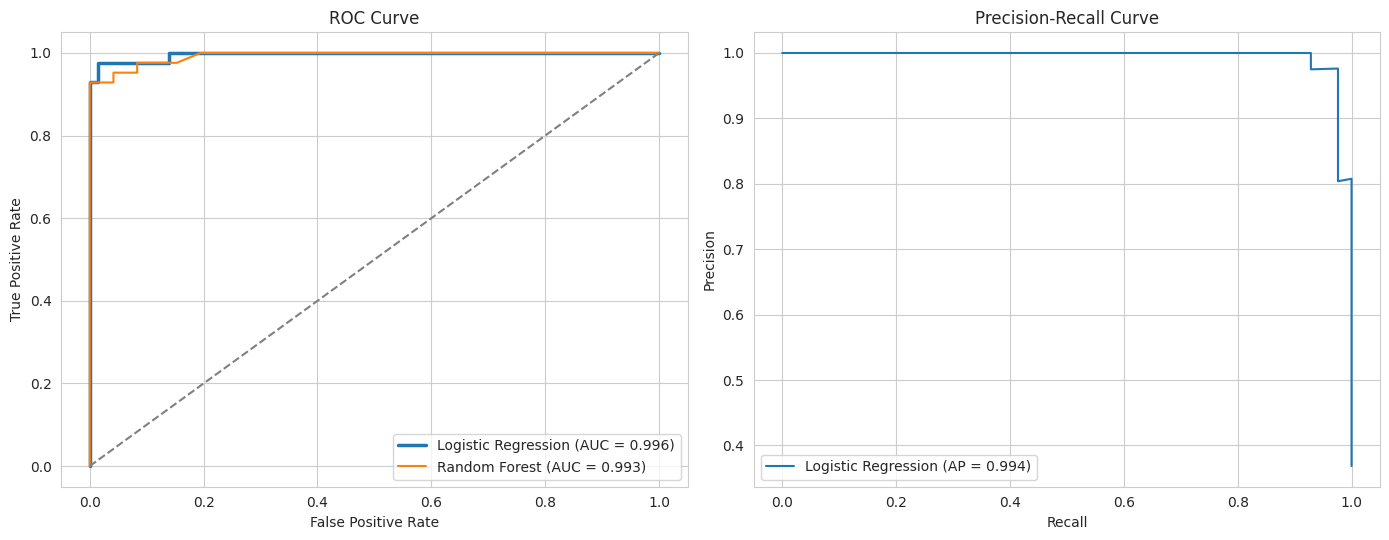

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for name, search in searches.items():
    prob = search.best_estimator_.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    lw = 2.5 if name == best_name else 1.5
    axes[0].plot(fpr, tpr, lw=lw, label=f"{name} (AUC = {roc_auc_score(y_test, prob):.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend(loc="lower right")

precisions, recalls, _ = precision_recall_curve(y_test, y_prob)
axes[1].plot(recalls, precisions,
             label=f"{best_name} (AP = {average_precision_score(y_test, y_prob):.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.savefig("images/roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Feature Importance

Logistic Regression coefficients (on standardised features, so they are comparable) next to Random Forest impurity importances.

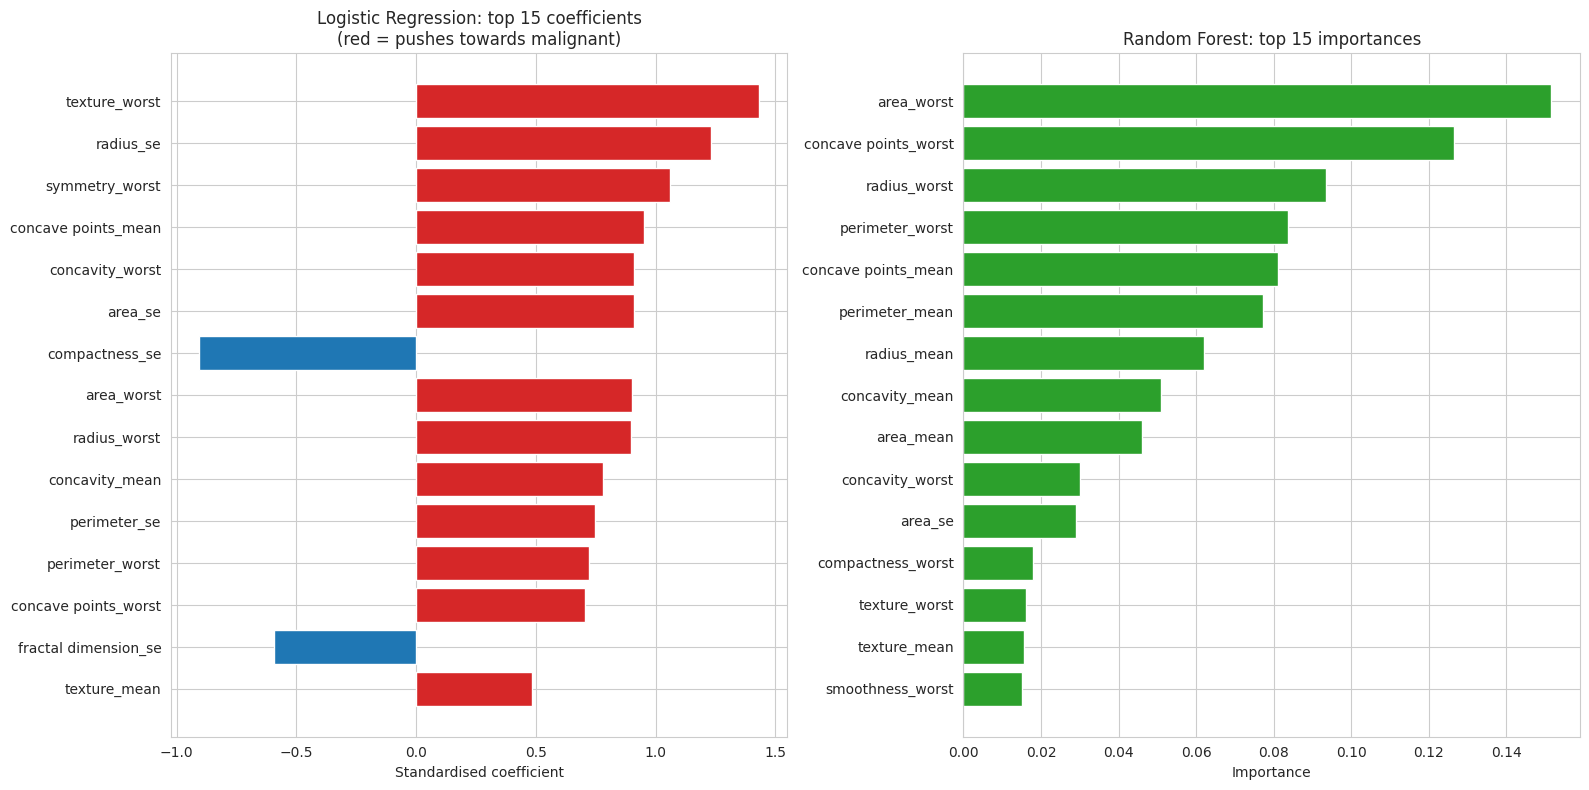

Features in the top 15 of both models: ['area_se', 'area_worst', 'concave points_mean', 'concave points_worst', 'concavity_mean', 'concavity_worst', 'perimeter_worst', 'radius_worst', 'texture_mean', 'texture_worst']


In [17]:
lr_coef = pd.Series(
    searches["Logistic Regression"].best_estimator_.named_steps["model"].coef_[0],
    index=X.columns)
rf_imp = pd.Series(
    searches["Random Forest"].best_estimator_.named_steps["model"].feature_importances_,
    index=X.columns)

top_lr = lr_coef.reindex(lr_coef.abs().sort_values(ascending=False).index)[:15]
top_rf = rf_imp.sort_values(ascending=False)[:15]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].barh(top_lr.index[::-1], top_lr.values[::-1],
             color=["tab:red" if v > 0 else "tab:blue" for v in top_lr.values[::-1]])
axes[0].set_title("Logistic Regression: top 15 coefficients\n(red = pushes towards malignant)")
axes[0].set_xlabel("Standardised coefficient")

axes[1].barh(top_rf.index[::-1], top_rf.values[::-1], color="tab:green")
axes[1].set_title("Random Forest: top 15 importances")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

print("Features in the top 15 of both models:",
      sorted(set(top_lr.index) & set(top_rf.index)))

**Takeaways**
- Both models agree that size and concavity features matter: 10 of the top 15 features overlap (e.g. `concave points_worst`, `perimeter_worst`, `radius_worst`, `area_worst`, `concavity_worst`).
- The rankings also differ (e.g. Logistic Regression puts `texture_worst`, `radius_se` and `symmetry_worst` near the top). With many strongly correlated features, Logistic Regression can shift weight between them, so coefficients should not be read as independent effects. Treat both plots as a rough guide, not as causal evidence.

## 10. Decision-Threshold Analysis

In cancer screening a **false negative** (a missed malignant tumour) is far more costly than a false positive (an extra follow-up). So instead of the default 0.5 cut-off, we look for a threshold that favours recall.

To avoid tuning on the test set, the threshold is chosen using **out-of-fold predictions on the training data only**, by maximising the F2 score (which weights recall twice as much as precision). The test set is used once, afterwards, to check the result.

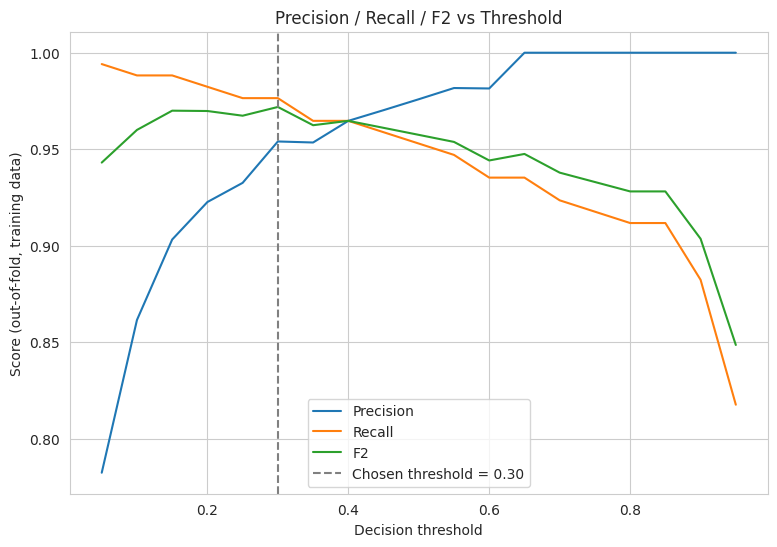

Threshold chosen on training data (max F2): 0.30


In [18]:
# Out-of-fold probabilities on the TRAINING set only
oof_prob = cross_val_predict(clone(best_model), X_train, y_train,
                             cv=outer_cv, method="predict_proba")[:, 1]

thresholds = np.linspace(0.05, 0.95, 19)
sweep = pd.DataFrame({
    "threshold": thresholds,
    "precision": [precision_score(y_train, oof_prob >= t, zero_division=0) for t in thresholds],
    "recall":    [recall_score(y_train, oof_prob >= t) for t in thresholds],
    "f2":        [fbeta_score(y_train, oof_prob >= t, beta=2) for t in thresholds],
})
best_thr = float(sweep.loc[sweep["f2"].idxmax(), "threshold"])

plt.figure(figsize=(9, 6))
plt.plot(sweep["threshold"], sweep["precision"], label="Precision")
plt.plot(sweep["threshold"], sweep["recall"], label="Recall")
plt.plot(sweep["threshold"], sweep["f2"], label="F2")
plt.axvline(best_thr, color="gray", ls="--", label=f"Chosen threshold = {best_thr:.2f}")
plt.xlabel("Decision threshold")
plt.ylabel("Score (out-of-fold, training data)")
plt.title("Precision / Recall / F2 vs Threshold")
plt.legend()
plt.show()

print(f"Threshold chosen on training data (max F2): {best_thr:.2f}")

### 10.1 Check on the test set: default vs chosen threshold

,accuracy,precision,recall,f1,roc_auc,FP,FN
threshold 0.50,0.965,0.975,0.929,0.951,0.996,1,3
threshold 0.30,0.982,0.976,0.976,0.976,0.996,1,1


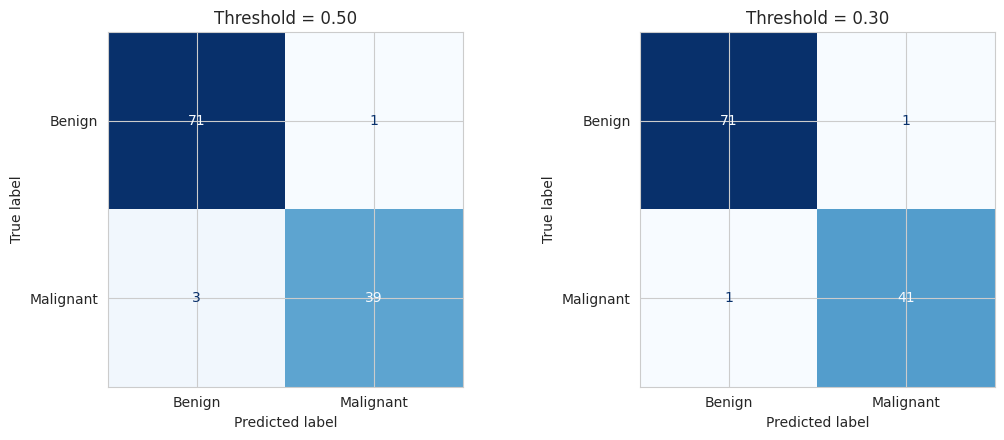

In [19]:
compare = pd.DataFrame({
    "threshold 0.50": evaluate(best_model, 0.5),
    f"threshold {best_thr:.2f}": evaluate(best_model, best_thr),
}).T
compare[["FP", "FN"]] = compare[["FP", "FN"]].astype(int)
display(compare.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, thr in zip(axes, [0.5, best_thr]):
    pred = (y_prob >= thr).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                           display_labels=["Benign", "Malignant"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Threshold = {thr:.2f}")
plt.tight_layout()
plt.show()

### 10.2 How much can we trust a 114-sample test set?

With only 114 test samples (42 malignant), a single patient moves recall by ~2.4 percentage points. A bootstrap over the test set gives a rough 95% interval.

In [20]:
rng = np.random.default_rng(RANDOM_STATE)
y_true = y_test.to_numpy()
final_pred = (y_prob >= best_thr).astype(int)

boot = []
for _ in range(2000):
    idx = rng.integers(0, len(y_true), len(y_true))
    if y_true[idx].sum() == 0:
        continue
    boot.append((recall_score(y_true[idx], final_pred[idx]),
                 precision_score(y_true[idx], final_pred[idx], zero_division=0)))

(rec_lo, prec_lo), (rec_hi, prec_hi) = np.percentile(boot, [2.5, 97.5], axis=0)
print(f"Recall    at threshold {best_thr:.2f}: {recall_score(y_true, final_pred):.3f}  (95% CI {rec_lo:.3f} - {rec_hi:.3f})")
print(f"Precision at threshold {best_thr:.2f}: {precision_score(y_true, final_pred):.3f}  (95% CI {prec_lo:.3f} - {prec_hi:.3f})")

Recall    at threshold 0.30: 0.976  (95% CI 0.921 - 1.000)
Precision at threshold 0.30: 0.976  (95% CI 0.917 - 1.000)


**Takeaways**
- The threshold of 0.30 was picked using only out-of-fold predictions on the training set (maximum F2).
- On the untouched test set, moving from 0.50 to 0.30 reduced false negatives from 3 to 1 with the false-positive count unchanged at 1: recall went from 0.929 to 0.976, precision stayed at about 0.976, and accuracy rose from 0.965 to 0.982.
- **Caveat:** this is 2 fewer missed cases on 114 samples. The bootstrap interval for recall (roughly 0.92 to 1.00) is wide, so this is encouraging evidence that a lower threshold helps, not proof of a precise improvement.

## 11. Conclusions and Limitations

**Summary**
- A regularised Logistic Regression matched or beat a tuned Random Forest under nested cross-validation (ROC-AUC 0.995), and it is simpler and faster.
- Choosing the decision threshold on training data to prioritise recall reduced missed malignant cases on the test set from 3 to 1 without adding false positives.

**Limitations**
- Small dataset (569 samples) and a single 80/20 hold-out split, so test metrics have wide uncertainty (see the bootstrap intervals).
- Features are pre-extracted from images; the data comes from one source and has no external validation.
- Feature-importance results are affected by strong multicollinearity.
- Probabilities were not calibrated, and no clinical cost model was used to set the threshold.
- Not validated for any clinical use.

**Possible next steps**
- Repeated nested CV to tighten the estimates
- Calibration curves, and gradient boosting / SVM baselines
- Permutation importance or SHAP, with grouped correlated features